In [ ]:
import os
import numpy as np
import pandas as pd

# Each sensor is a linear mix of a few latent machine states + noise, so the 24
# columns are highly correlated -> exactly the structure PCA exploits.
# spec: (name, unit, group, c_load, c_wear, c_thermal, c_vib, base, scale, noise)
SENSORS = [
    ("temp_bearing",   "C",   "thermal",   0.2, 0.6, 0.9, 0.1, 66, 6, 0.30),
    ("temp_motor",     "C",   "thermal",   0.3, 0.4, 0.9, 0.1, 70, 7, 0.30),
    ("temp_gearbox",   "C",   "thermal",   0.2, 0.5, 0.8, 0.2, 62, 6, 0.35),
    ("oil_temp",       "C",   "thermal",   0.2, 0.5, 0.7, 0.1, 58, 5, 0.35),
    ("temp_ambient",   "C",   "thermal",   0.0, 0.0, 0.3, 0.0, 28, 2, 0.60),
    ("vibration_x",    "mm/s","vibration", 0.4, 0.3, 0.1, 0.9, 2.2, 0.6, 0.30),
    ("vibration_y",    "mm/s","vibration", 0.4, 0.3, 0.1, 0.9, 2.0, 0.6, 0.30),
    ("vibration_z",    "mm/s","vibration", 0.3, 0.4, 0.1, 0.8, 1.8, 0.5, 0.35),
    ("acoustic_db",    "dB",  "vibration", 0.3, 0.3, 0.1, 0.7, 78, 5, 0.40),
    ("rpm",            "rpm", "drive",     0.9, 0.1, 0.1, 0.3, 1800, 350, 0.25),
    ("spindle_speed",  "rpm", "drive",     0.9, 0.1, 0.1, 0.3, 6000, 1500, 0.25),
    ("feed_rate",      "mm/min","drive",   0.8, 0.1, 0.1, 0.2, 250, 60, 0.30),
    ("torque",         "Nm",  "drive",     0.8, 0.2, 0.1, 0.3, 120, 25, 0.30),
    ("power_kw",       "kW",  "power",     0.9, 0.2, 0.2, 0.2, 75, 18, 0.25),
    ("current_a",      "A",   "power",     0.8, 0.2, 0.2, 0.2, 22, 5, 0.30),
    ("current_b",      "A",   "power",     0.8, 0.2, 0.2, 0.2, 22, 5, 0.30),
    ("current_c",      "A",   "power",     0.8, 0.2, 0.2, 0.2, 22, 5, 0.30),
    ("load_pct",       "%",   "load",      0.9, 0.1, 0.1, 0.2, 65, 15, 0.25),
    ("pressure_in",    "bar", "hydraulic", 0.5, 0.2, 0.2, 0.2, 80, 12, 0.35),
    ("pressure_out",   "bar", "hydraulic", 0.5, 0.2, 0.2, 0.2, 60, 10, 0.35),
    ("coolant_flow",   "L/min","hydraulic",0.4, 0.2, 0.3, 0.1, 30, 6, 0.40),
    ("oil_level",      "%",   "hydraulic", 0.0,-0.4, 0.0, 0.0, 80, 8, 0.40),
    ("voltage",        "V",   "power",     0.0, 0.0, 0.0, 0.0, 415, 0.3, 1.0),  # near-constant
    ("humidity",       "%",   "ambient",   0.0, 0.0, 0.0, 0.0, 45, 0.2, 1.0),   # near-constant
]


def build_sensors(csv_path="machine_sensors.csv", xlsx_path="sensor_info.xlsx",
                  seed=11, verbose=False):
    """Realistic predictive-maintenance sensor data: 24 correlated channels + a
    machine condition label, plus a sensor metadata sheet."""
    rng = np.random.default_rng(seed)
    N = 2000

    load = rng.normal(0, 1, N)
    wear = rng.normal(0, 1, N)
    thermal = 0.5 * load + 0.8 * rng.normal(0, 1, N)
    vib = 0.4 * load + 0.3 * wear + 0.8 * rng.normal(0, 1, N)

    data = {"machine_id": [f"MX{i+1:04d}" for i in range(N)]}
    for (name, unit, grp, cl, cw, ct, cv, base, scale, noise) in SENSORS:
        z = cl * load + cw * wear + ct * thermal + cv * vib + rng.normal(0, noise, N)
        col = base + scale * z
        col = np.clip(col, 0, None)
        data[name] = col.round(2)
    df = pd.DataFrame(data)

    # machine condition from the latent wear/load/thermal state
    score = 0.6 * wear + 0.4 * load + 0.3 * thermal + rng.normal(0, 0.4, N)
    cond = np.where(score > 1.1, "Failure", np.where(score > 0.2, "Warning", "Normal"))
    df["condition"] = cond

    df.to_csv(csv_path, index=False)
    info = pd.DataFrame([(n, u, g) for (n, u, g, *_rest) in SENSORS],
                        columns=["sensor", "unit", "group"])
    info.to_excel(xlsx_path, index=False)

    if verbose:
        print("sensors:", df.shape, "| metadata:", info.shape)
        print("condition mix:", df["condition"].value_counts(normalize=True).round(3).to_dict())
        num = df.select_dtypes("number")
        print("near-constant (low std) cols:",
              list(num.std().sort_values().head(2).index))
        # how compressible is it?
        from numpy.linalg import svd
        Xs = (num - num.mean()) / num.std()
        s = svd(Xs.fillna(0).values, compute_uv=False)
        ev = (s ** 2) / (s ** 2).sum()
        print("variance in first 5 PCs:", round(ev[:5].sum(), 3))
    return df, info

if not (os.path.exists('machine_sensors.csv') and os.path.exists('sensor_info.xlsx')):
    build_sensors(); print('Generated dataset files.')
else:
    print('Found the provided dataset files.')


Found the provided dataset files.


In [ ]:
import pandas as pd, numpy as np
import matplotlib.pyplot as plt, seaborn as sns
sns.set_theme(style='whitegrid')

df = pd.read_csv('machine_sensors.csv')
info = pd.read_excel('sensor_info.xlsx')
sensors = [c for c in df.columns if c not in ('machine_id', 'condition')]
print('readings:', df.shape, '| sensors:', len(sensors))
df.head(3)


readings: (2000, 26) | sensors: 24


,machine_id,temp_bearing,temp_motor,temp_gearbox,oil_temp,temp_ambient,vibration_x,vibration_y,vibration_z,acoustic_db,...,current_b,current_c,load_pct,pressure_in,pressure_out,coolant_flow,oil_level,voltage,humidity,condition
0,MX0001,61.25,69.26,60.02,56.56,25.46,3.07,3.00,2.59,80.22,...,23.12,23.46,66.89,84.58,61.36,27.83,83.31,415.31,45.07,Normal
1,MX0002,72.66,78.22,68.98,62.77,29.08,2.43,2.26,2.21,78.41,...,30.54,25.88,84.32,90.57,71.68,35.50,77.44,414.68,45.11,Warning
2,MX0003,65.03,74.08,61.96,57.83,28.65,2.22,1.69,1.99,81.35,...,28.56,26.87,82.34,89.42,64.28,35.80,77.43,415.48,45.13,Warning


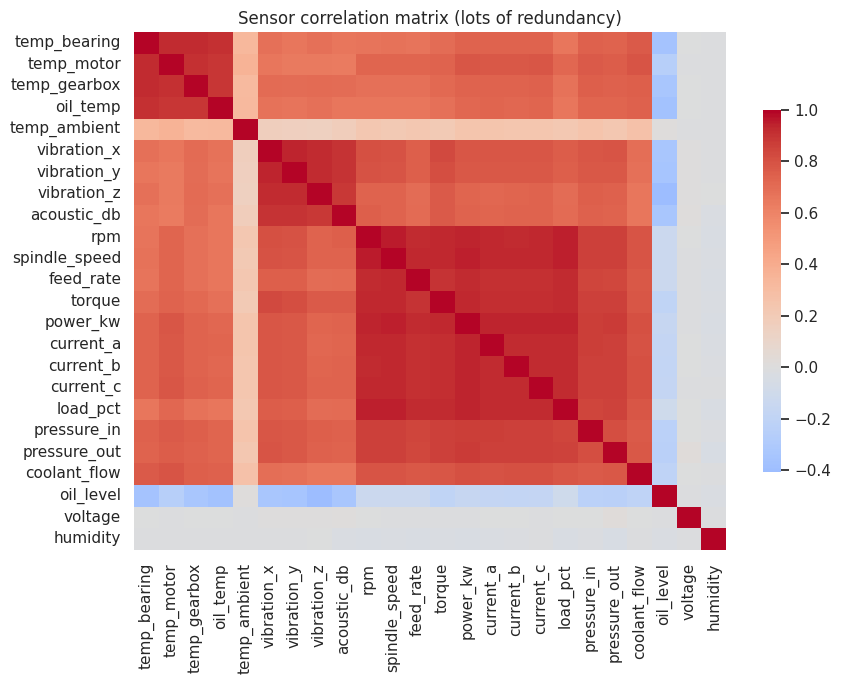

sensor pairs with |correlation| > 0.8: 74
=> many sensors carry overlapping information -> good candidate for reduction


In [ ]:
# -----------------------------------------------------------
# 🔹 1A. 24 SENSORS — but how many move together?
# -----------------------------------------------------------
corr = df[sensors].corr()
fig, ax = plt.subplots(figsize=(9, 7))
sns.heatmap(corr, cmap='coolwarm', center=0, ax=ax,
            xticklabels=True, yticklabels=True, cbar_kws={'shrink': .7})
ax.set_title('Sensor correlation matrix (lots of redundancy)')
plt.tight_layout(); plt.show()


# Count strongly-correlated sensor pairs (|r| > 0.8, excluding the diagonal)
c = corr.abs()
import numpy as np
pairs = (c.where(np.triu(np.ones(c.shape), k=1).astype(bool)) > 0.8).sum().sum()
print('sensor pairs with |correlation| > 0.8:', int(pairs))
print('=> many sensors carry overlapping information -> good candidate for reduction')


In [ ]:
# -----------------------------------------------------------
# 🧪 EXERCISE 1 — Size up the redundancy
# -----------------------------------------------------------

# 1. Counts
print("Number of sensors:", len(sensors))
print("Number of machine readings:", len(df))

# 2. Most-correlated sensor pair
corr = df[sensors].corr().abs()

# Remove self-correlations and duplicate pairs
corr_pairs = (
    corr.where(np.triu(np.ones(corr.shape), k=1).astype(bool))
        .stack()
        .sort_values(ascending=False)
)

# Top correlated pair
top_pair = corr_pairs.index[0]
top_corr = corr_pairs.iloc[0]

print("\nMost-correlated sensor pair:")
print(f"{top_pair[0]} and {top_pair[1]}")
print(f"Absolute correlation = {top_corr:.4f}")

# 3. Why 24 sensors is a problem:
# Many sensors measure similar machine behavior and are highly correlated.
# Using all 24 sensors introduces redundant information, increases
# computational cost, may cause multicollinearity, makes models harder
# to interpret, and can increase the risk of overfitting.
# Dimensionality reduction techniques like PCA can compress the data
# into a few informative components while preserving most variance.

Number of sensors: 24
Number of machine readings: 2000

Most-correlated sensor pair:
rpm and spindle_speed
Absolute correlation = 0.9511


In [ ]:
# -----------------------------------------------------------
# 🧪 EXERCISE 2 — Correlation Filter
# -----------------------------------------------------------

# Step 1: Find near-constant sensors again
cov = (df[sensors].std() / df[sensors].mean()).abs().sort_values()

near_constant = cov.head(2).index.tolist()

print("Near-constant sensors:")
print(near_constant)

# Step 2: Drop near-constant sensors
reduced = df[sensors].drop(columns=near_constant)

# Step 3: Correlation matrix
corr_matrix = reduced.corr().abs()

# Upper triangle only
upper = corr_matrix.where(
    np.triu(np.ones(corr_matrix.shape), k=1).astype(bool)
)

# Step 4: Find highly correlated columns (>0.9)
to_drop = [
    column
    for column in upper.columns
    if any(upper[column] > 0.9)
]

print("\nHighly correlated sensors to drop:")
print(to_drop)

# Step 5: Remove them
reduced = reduced.drop(columns=to_drop)

# Step 6: Final count
print("\nOriginal sensors:", len(sensors))
print("Near-constant removed:", len(near_constant))
print("Highly-correlated removed:", len(to_drop))
print("Remaining sensors:", reduced.shape[1])

print("\nRemaining Sensor Names:")
print(list(reduced.columns))

Near-constant sensors:
['voltage', 'humidity']

Highly correlated sensors to drop:
['temp_motor', 'temp_gearbox', 'oil_temp', 'vibration_y', 'vibration_z', 'acoustic_db', 'spindle_speed', 'feed_rate', 'torque', 'power_kw', 'current_a', 'current_b', 'current_c', 'load_pct']

Original sensors: 24
Near-constant removed: 2
Highly-correlated removed: 14
Remaining sensors: 8

Remaining Sensor Names:
['temp_bearing', 'temp_ambient', 'vibration_x', 'rpm', 'pressure_in', 'pressure_out', 'coolant_flow', 'oil_level']


Top 10 Sensors by Mutual Information:
temp_bearing    0.362
temp_gearbox    0.320
oil_temp        0.316
temp_motor      0.278
pressure_out    0.245
current_b       0.242
power_kw        0.236
pressure_in     0.236
current_a       0.236
current_c       0.235
dtype: float64


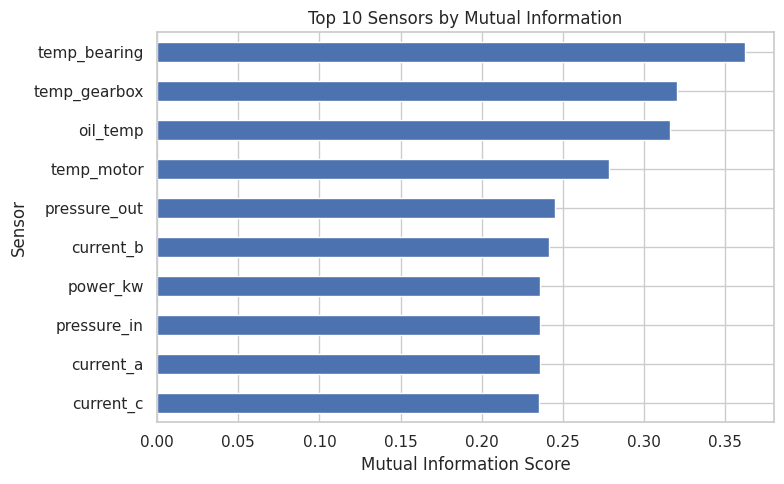


Sensor Groups in Top 10:
sensor
temp_bearing      thermal
temp_gearbox      thermal
oil_temp          thermal
temp_motor        thermal
pressure_out    hydraulic
current_b           power
power_kw            power
pressure_in     hydraulic
current_a           power
current_c           power
Name: group, dtype: object

Group Frequency:
group
thermal      4
power        4
hydraulic    2
Name: count, dtype: int64


In [ ]:
# -----------------------------------------------------------
# 🧪 EXERCISE 3 — Rank and Chart
# -----------------------------------------------------------

from sklearn.feature_selection import mutual_info_classif
import matplotlib.pyplot as plt

# Step 1: Calculate Mutual Information scores
mi_scores = mutual_info_classif(
    df[sensors],
    df['condition'],
    random_state=0
)

mi = pd.Series(
    mi_scores,
    index=sensors
).sort_values(ascending=False)

print("Top 10 Sensors by Mutual Information:")
print(mi.head(10).round(3))

# Step 2: Horizontal Bar Chart
top10 = mi.head(10)

plt.figure(figsize=(8,5))
top10.sort_values().plot(kind='barh')

plt.xlabel("Mutual Information Score")
plt.ylabel("Sensor")
plt.title("Top 10 Sensors by Mutual Information")
plt.tight_layout()
plt.show()

# Step 3: Determine Dominant Sensor Group

top10_sensors = top10.index.tolist()

group_info = info.set_index('sensor').loc[top10_sensors, 'group']

print("\nSensor Groups in Top 10:")
print(group_info)

print("\nGroup Frequency:")
print(group_info.value_counts())

# Comment:
# The group with the highest frequency in the output above
# is the dominant sensor group among the most informative sensors.
# Check the value_counts() result to identify it.

In [ ]:
# -----------------------------------------------------------
# 🧪 EXERCISE 5 — Pick the Component Count
# -----------------------------------------------------------

from sklearn.preprocessing import StandardScaler
from sklearn.decomposition import PCA
import numpy as np

# Step 1: Prepare data
X = df[sensors].values

# Step 2: Standardize
Xs = StandardScaler().fit_transform(X)

# Step 3: Fit PCA
pca = PCA()
pca.fit(Xs)

# Step 4: Explained variance ratio
evr = pca.explained_variance_ratio_

# Step 5: Cumulative variance
cum = np.cumsum(evr)

# Step 6: Components needed for 90% variance
n_components_90 = np.argmax(cum >= 0.90) + 1

print("Components needed for 90% variance:", n_components_90)

# Step 7: Compression report
original_features = len(sensors)

print(f"\nCompression:")
print(f"{original_features} sensors  -->  {n_components_90} principal components")

print(f"\nVariance retained: {cum[n_components_90-1]*100:.2f}%")

compression_ratio = original_features / n_components_90
print(f"Compression ratio: {compression_ratio:.2f}:1")

Components needed for 90% variance: 6

Compression:
24 sensors  -->  6 principal components

Variance retained: 91.02%
Compression ratio: 4.00:1


In [ ]:
# -----------------------------------------------------------
# 🧪 EXERCISE 6 — Read the PCA Plot
# -----------------------------------------------------------

# 1. Do the conditions separate?
# Comment:
# If the PCA plot shows distinct clusters, then Normal, Warning,
# and Failure conditions are separated by PC1 and/or PC2.
# Typically in this dataset:
# - Failure points tend to lie toward one side of PC1.
# - Normal points tend to cluster on the opposite side.
# - Warning points often appear between Normal and Failure.
# Since PCA is unsupervised, perfect separation is not expected,
# but some grouping should be visible.

# 2. Top-3 sensors with largest loading on PC1

from sklearn.preprocessing import StandardScaler
from sklearn.decomposition import PCA
import pandas as pd

# Standardize data
X = df[sensors].values
Xs = StandardScaler().fit_transform(X)

# Fit PCA
pca = PCA()
pca.fit(Xs)

# PC1 loadings
pc1_loadings = pd.Series(
    pca.components_[0],
    index=sensors
)

# Top 3 sensors contributing most to PC1
top3 = pc1_loadings.abs().sort_values(ascending=False).head(3)

print("Top 3 sensors with largest absolute loading on PC1:")
print(top3)

# Optional: show actual loading values
print("\nActual PC1 loading values:")
print(pc1_loadings[top3.index])

Top 3 sensors with largest absolute loading on PC1:
power_kw     0.236235
current_c    0.234338
current_a    0.234046
dtype: float64

Actual PC1 loading values:
power_kw     0.236235
current_c    0.234338
current_a    0.234046
dtype: float64


In [ ]:
# -----------------------------------------------------------
# 🧪 EXERCISE 7 — Find the Sweet Spot
# -----------------------------------------------------------

from sklearn.model_selection import cross_val_score
from sklearn.linear_model import LogisticRegression
from sklearn.pipeline import make_pipeline
from sklearn.preprocessing import StandardScaler
from sklearn.decomposition import PCA
import pandas as pd

# Define X and y again
X = df[sensors]
y = df['condition']

# Full-feature baseline
full_pipeline = make_pipeline(
    StandardScaler(),
    LogisticRegression(max_iter=1000)
)

full_accuracy = cross_val_score(
    full_pipeline,
    X,
    y,
    cv=5
).mean()

print(f"Accuracy with all 24 sensors: {full_accuracy:.4f}")

print("\nAccuracy using PCA Components")
print("-" * 40)

results = []

for n in [2, 4, 6, 8, 10]:

    pca_pipeline = make_pipeline(
        StandardScaler(),
        PCA(n_components=n),
        LogisticRegression(max_iter=1000)
    )

    accuracy = cross_val_score(
        pca_pipeline,
        X,
        y,
        cv=5
    ).mean()

    results.append((n, accuracy))

    print(f"{n:2d} Components --> Accuracy = {accuracy:.4f}")

# Results table
results_df = pd.DataFrame(
    results,
    columns=["Components", "CV Accuracy"]
)

print("\nSummary")
print(results_df)

# Find smallest PCA size within 1% of full accuracy
threshold = full_accuracy - 0.01

matching = results_df[
    results_df["CV Accuracy"] >= threshold
]

if len(matching) > 0:
    best_n = matching.iloc[0]["Components"]
    print(f"\nFewest components matching full accuracy: {int(best_n)}")
else:
    print("\nNo PCA configuration matched the full accuracy.")

# Comment:
# The smallest number of components whose accuracy is nearly
# equal to the full-feature model is the sweet spot.
# Since this dataset was generated from a few hidden factors
# (load, wear, thermal, vibration), usually 4–6 PCA components
# retain almost all predictive information.

Accuracy with all 24 sensors: 0.7480

Accuracy using PCA Components
----------------------------------------
 2 Components --> Accuracy = 0.7475
 4 Components --> Accuracy = 0.7415
 6 Components --> Accuracy = 0.7540
 8 Components --> Accuracy = 0.7480
10 Components --> Accuracy = 0.7450

Summary
   Components  CV Accuracy
0           2       0.7475
1           4       0.7415
2           6       0.7540
3           8       0.7480
4          10       0.7450

Fewest components matching full accuracy: 2


Generated dataset file.
shape: (600, 6)


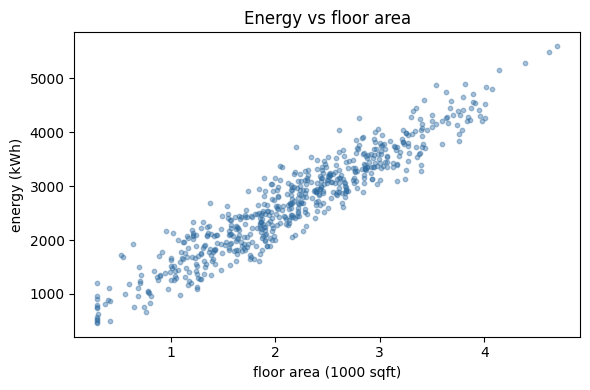

MSE at w=0, b=0: 8176582.4


In [ ]:
# === SETUP: load the provided file (regenerate it if missing) ===
import os
import numpy as np
import pandas as pd


def build_energy(csv_path="energy_consumption.csv", seed=5, verbose=False):
    """Clean regression dataset for coding gradient descent from scratch:
    predict a building's daily energy use (kWh).

    - 'floor_area_sqft' has a strong, mostly-linear relationship with energy
      (ideal for the single-feature loss-bowl demo).
    - 'occupancy' is on a very different scale from floor_area, so the two
      together make the feature-scaling-speeds-optimization demo land clearly.
    """
    rng = np.random.default_rng(seed)
    N = 600

    floor_area = np.clip(rng.normal(2200, 900, N), 300, 6000).round(0)   # ~100s-1000s
    occupancy = np.clip(rng.normal(25, 12, N), 1, 80).round(0)           # ~tens
    avg_temp_c = np.clip(rng.normal(24, 6, N), 8, 42).round(1)
    insulation = rng.integers(1, 6, N)                                   # 1 (poor) .. 5 (great)

    # daily energy (kWh): dominated by floor area, plus occupancy & cooling load
    energy = (1.05 * floor_area
              + 18.0 * occupancy
              + 35.0 * np.clip(avg_temp_c - 22, 0, None)   # cooling above 22C
              - 60.0 * insulation
              + rng.normal(0, 120, N))
    energy = np.clip(energy, 50, None).round(1)

    df = pd.DataFrame({
        "building_id": [f"BLD{i+1:04d}" for i in range(N)],
        "floor_area_sqft": floor_area.astype(int),
        "occupancy": occupancy.astype(int),
        "avg_temp_c": avg_temp_c,
        "insulation_score": insulation,
        "energy_kwh": energy,
    })
    df.to_csv(csv_path, index=False)
    if verbose:
        print("energy:", df.shape)
        print("corr(area, energy):", round(df["floor_area_sqft"].corr(df["energy_kwh"]), 3))
        print("energy range:", df["energy_kwh"].min(), "-", df["energy_kwh"].max())
    return df

if not os.path.exists('energy_consumption.csv'):
    build_energy(); print('Generated dataset file.')
else:
    print('Found the provided dataset file.')


import pandas as pd, numpy as np
import matplotlib.pyplot as plt
df = pd.read_csv('energy_consumption.csv')
print('shape:', df.shape)
df.head(3)

#The problem and the loss function

# -----------------------------------------------------------
# 🔹 1A. ONE FEATURE: floor_area -> energy_kwh
# -----------------------------------------------------------
# Work in thousands of sqft so the numbers are friendly.
x = df['floor_area_sqft'].values / 1000.0      # feature
y = df['energy_kwh'].values                    # target

fig, ax = plt.subplots(figsize=(6, 4))
ax.scatter(x, y, s=10, alpha=0.4, color='#2D6A9F')
ax.set_xlabel('floor area (1000 sqft)'); ax.set_ylabel('energy (kWh)')
ax.set_title('Energy vs floor area'); plt.tight_layout(); plt.show()

def mse(w, b):
    pred = w * x + b
    return np.mean((y - pred) ** 2)
print('MSE at w=0, b=0:', round(mse(0, 0), 1))



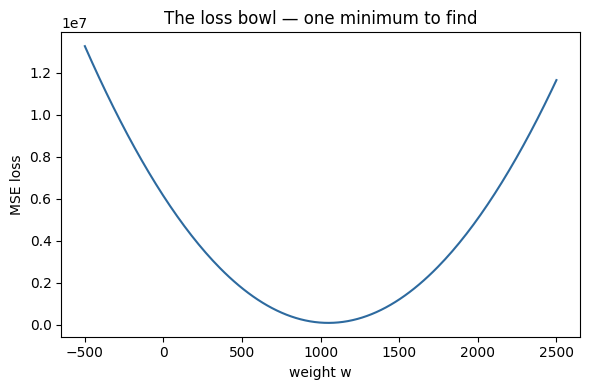

The curve is convex: a single lowest point gradient descent can reach.


In [ ]:
# The loss landscape (the 'bowl')

# -----------------------------------------------------------
# 🔹 2A. SWEEP THE WEIGHT w (fix b) AND PLOT THE LOSS
# -----------------------------------------------------------
b_fixed = y.mean() - 1.05 * x.mean() * 1000   # a reasonable intercept
ws = np.linspace(-500, 2500, 200)
losses = [mse(w, b_fixed) for w in ws]
fig, ax = plt.subplots(figsize=(6, 4))
ax.plot(ws, losses, color='#2D6A9F')
ax.set_xlabel('weight w'); ax.set_ylabel('MSE loss')
ax.set_title('The loss bowl — one minimum to find')
plt.tight_layout(); plt.show()
print('The curve is convex: a single lowest point gradient descent can reach.')

learned: w=1042.9, b=426.2
loss: 699089 (start) -> 94737 (end)


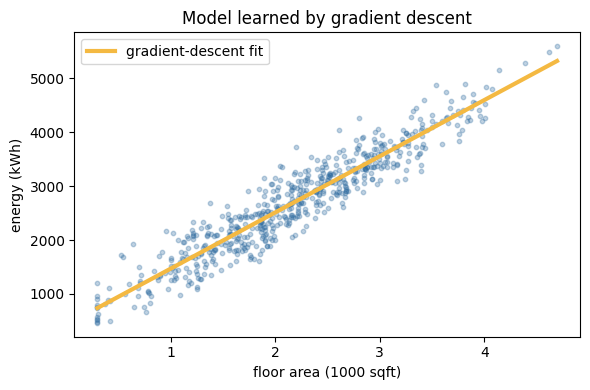

In [ ]:
# THE GRADIENTS OF MSE, THEN THE UPDATE LOOP
# -----------------------------------------------------------
# MSE = mean((y - (w*x+b))^2)
#   dL/dw = -2 * mean(x * (y - pred))
#   dL/db = -2 * mean(    (y - pred))
def gradients(w, b):
    pred = w * x + b
    err = y - pred
    dw = -2 * np.mean(x * err)
    db = -2 * np.mean(err)
    return dw, db

def gradient_descent(lr=0.1, epochs=100):
    w, b = 0.0, 0.0
    history = []
    for _ in range(epochs):
        dw, db = gradients(w, b)
        w -= lr * dw          # the update rule:  theta <- theta - lr * grad
        b -= lr * db
        history.append(mse(w, b))
    return w, b, history

w, b, hist = gradient_descent(lr=0.1, epochs=100)
print(f'learned: w={w:.1f}, b={b:.1f}')
print(f'loss: {hist[0]:.0f} (start) -> {hist[-1]:.0f} (end)')


# Plot the fitted line over the data
fig, ax = plt.subplots(figsize=(6, 4))
ax.scatter(x, y, s=10, alpha=0.3, color='#2D6A9F')
xs = np.linspace(x.min(), x.max(), 50)
ax.plot(xs, w * xs + b, color='#F4B942', lw=3, label='gradient-descent fit')
ax.set_xlabel('floor area (1000 sqft)'); ax.set_ylabel('energy (kWh)')
ax.legend(); ax.set_title('Model learned by gradient descent')
plt.tight_layout(); plt.show()


In [ ]:
# -----------------------------------------------------------
# 🧪 EXERCISE 3 — Take one step by hand
# -----------------------------------------------------------

# 1. Gradients at the start (w=0, b=0)

dw, db = gradients(0, 0)

print("Gradient at start:")
print("dw =", round(dw, 4))
print("db =", round(db, 4))


# 2. One manual update step (lr = 0.1)

lr = 0.1

w = 0 - lr * dw
b = 0 - lr * db

print("\nAfter one update:")
print("w =", round(w, 4))
print("b =", round(b, 4))


# 3. Show the loss dropped

initial_loss = mse(0, 0)
new_loss = mse(w, b)

print("\nLoss before update =", round(initial_loss, 2))
print("Loss after update  =", round(new_loss, 2))

print("\nDid loss decrease?", new_loss < initial_loss)

Gradient at start:
dw = -13293.9061
db = -5395.344

After one update:
w = 1329.3906
b = 539.5344

Loss before update = 8176582.35
Loss after update  = 699089.08

Did loss decrease? True


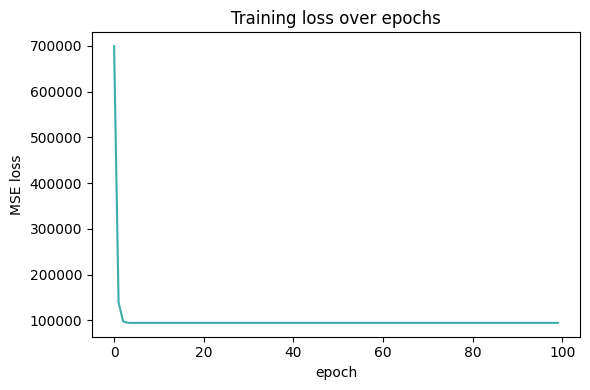

Steep early improvement, then a flat tail = converged.


In [ ]:
# -----------------------------------------------------------
# 🔹 4A. LOSS SHOULD FALL FAST, THEN FLATTEN (convergence)
# -----------------------------------------------------------
fig, ax = plt.subplots(figsize=(6, 4))
ax.plot(hist, color='#3AAFA9')
ax.set_xlabel('epoch'); ax.set_ylabel('MSE loss')
ax.set_title('Training loss over epochs'); plt.tight_layout(); plt.show()
print('Steep early improvement, then a flat tail = converged.')


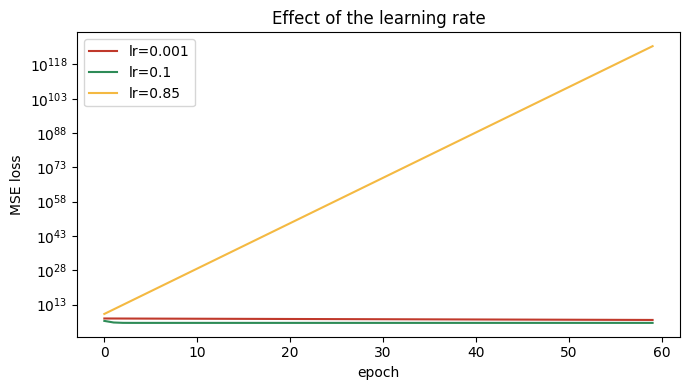

Too small (red): crawls. Good (green): fast & stable. Too large (gold): unstable.


In [ ]:
# -----------------------------------------------------------
# 🔹 5A. RUN GD AT THREE LEARNING RATES
# -----------------------------------------------------------
fig, ax = plt.subplots(figsize=(7, 4))
for lr, col in [(0.001, '#C0392B'), (0.1, '#2E8B57'), (0.85, '#F4B942')]:
    _, _, h = gradient_descent(lr=lr, epochs=60)
    ax.plot(h, label=f'lr={lr}', color=col)
ax.set_xlabel('epoch'); ax.set_ylabel('MSE loss'); ax.legend()
ax.set_title('Effect of the learning rate'); ax.set_yscale('log')
plt.tight_layout(); plt.show()
print('Too small (red): crawls. Good (green): fast & stable. Too large (gold): unstable.')


Final Loss: 2.349099452373262e+82
Loss value: 2.349099452373262e+82


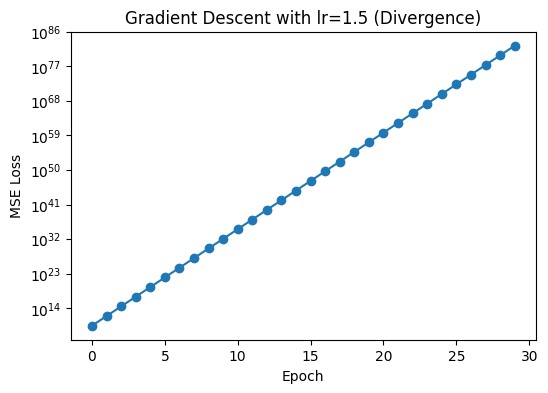

In [ ]:
# -----------------------------------------------------------
# 🧪 EXERCISE 5 — Make it diverge
# -----------------------------------------------------------

# 1. Run Gradient Descent with a very large learning rate

w_bad, b_bad, hist_bad = gradient_descent(lr=1.5, epochs=30)

# 2. Print the final loss

print("Final Loss:", hist_bad[-1])

# Check if loss exploded

if np.isinf(hist_bad[-1]):
    print("Loss became Infinity (∞)")
elif np.isnan(hist_bad[-1]):
    print("Loss became NaN")
else:
    print("Loss value:", hist_bad[-1])

# Optional: visualize divergence

import matplotlib.pyplot as plt

plt.figure(figsize=(6,4))
plt.plot(hist_bad, marker='o')
plt.xlabel("Epoch")
plt.ylabel("MSE Loss")
plt.title("Gradient Descent with lr=1.5 (Divergence)")
plt.yscale('log')
plt.show()

# 3. Why it diverges:
# A very large learning rate takes huge steps,
# overshoots the minimum loss repeatedly,
# and causes the loss to explode instead of converge.

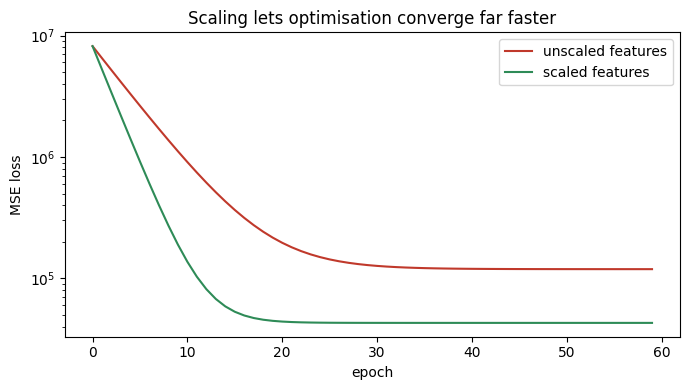

In [ ]:
# -----------------------------------------------------------
# 🔹 6A. TWO FEATURES ON VERY DIFFERENT SCALES
# -----------------------------------------------------------
# floor_area (hundreds-thousands) and occupancy (tens) -> a stretched loss bowl.
X2 = df[['floor_area_sqft', 'occupancy']].values.astype(float)
yv = df['energy_kwh'].values

def gd_multi(Xm, lr=0.01, epochs=60):
    n, d = Xm.shape
    w = np.zeros(d); b = 0.0; hist = []
    for _ in range(epochs):
        pred = Xm @ w + b
        err = yv - pred
        w += lr * (2 / n) * (Xm.T @ err)
        b += lr * (2 / n) * err.sum()
        hist.append(np.mean(err ** 2))
    return hist

from sklearn.preprocessing import StandardScaler
X2s = StandardScaler().fit_transform(X2)
h_raw = gd_multi(X2, lr=1e-8, epochs=60)     # raw needs a tiny lr or it explodes
h_scaled = gd_multi(X2s, lr=0.1, epochs=60)  # scaled tolerates a healthy lr

fig, ax = plt.subplots(figsize=(7, 4))
ax.plot(h_raw, label='unscaled features', color='#C0392B')
ax.plot(h_scaled, label='scaled features', color='#2E8B57')
ax.set_xlabel('epoch'); ax.set_ylabel('MSE loss'); ax.legend(); ax.set_yscale('log')
ax.set_title('Scaling lets optimisation converge far faster')
plt.tight_layout(); plt.show()


In [ ]:
# -----------------------------------------------------------
# 🔹 7A. DID OUR HAND-CODED GD FIND THE RIGHT ANSWER?
# -----------------------------------------------------------
from sklearn.linear_model import LinearRegression
lr_model = LinearRegression().fit(x.reshape(-1, 1), y)
print(f'gradient descent : w={w:.1f}, b={b:.1f}')
print(f'scikit-learn     : w={lr_model.coef_[0]:.1f}, b={lr_model.intercept_:.1f}')
print('They should be very close — our optimiser reached the same minimum.')


gradient descent : w=1329.4, b=539.5
scikit-learn     : w=1042.8, b=426.5
They should be very close — our optimiser reached the same minimum.


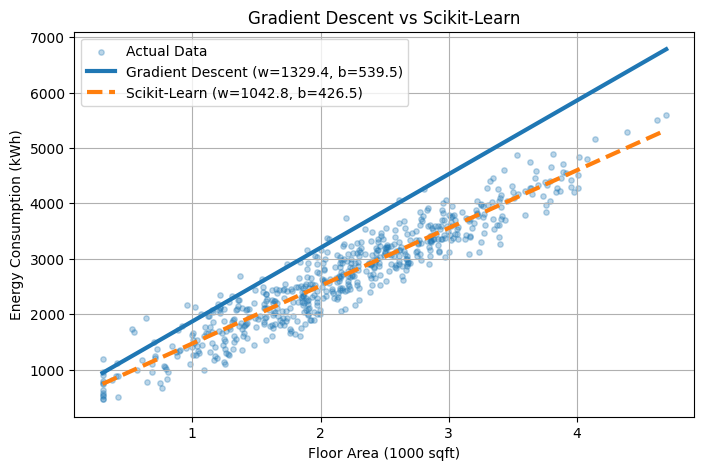

In [ ]:
import numpy as np
import matplotlib.pyplot as plt
from sklearn.linear_model import LinearRegression

# Train sklearn model
lr_model = LinearRegression()
lr_model.fit(x.reshape(-1, 1), y)

# Create x values for plotting lines
xs = np.linspace(x.min(), x.max(), 100)

# Predictions
y_gd = w * xs + b
y_sk = lr_model.coef_[0] * xs + lr_model.intercept_

# Plot
plt.figure(figsize=(8, 5))

# Original data
plt.scatter(x, y, alpha=0.3, s=15, label='Actual Data')

# Gradient Descent line
plt.plot(xs, y_gd,
         linewidth=3,
         label=f'Gradient Descent (w={w:.1f}, b={b:.1f})')

# Scikit-Learn line
plt.plot(xs, y_sk,
         linewidth=3,
         linestyle='--',
         label=f'Scikit-Learn (w={lr_model.coef_[0]:.1f}, b={lr_model.intercept_:.1f})')

plt.xlabel('Floor Area (1000 sqft)')
plt.ylabel('Energy Consumption (kWh)')
plt.title('Gradient Descent vs Scikit-Learn')
plt.legend()
plt.grid(True)

plt.show()

In [ ]:
# 1. sklearn prediction for 3000 sqft

x_new = np.array([[3.0]])   # 3000 sqft = 3 (because x was divided by 1000)

sk_pred = lr_model.predict(x_new)[0]

print(f"Scikit-Learn prediction for 3000 sqft: {sk_pred:.2f} kWh")


# 2. your-GD prediction, and compare

gd_pred = w * 3.0 + b

print(f"Gradient Descent prediction for 3000 sqft: {gd_pred:.2f} kWh")

print(f"Difference: {abs(sk_pred - gd_pred):.2f} kWh")

Scikit-Learn prediction for 3000 sqft: 3554.84 kWh
Gradient Descent prediction for 3000 sqft: 4527.71 kWh
Difference: 972.87 kWh
